In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load the monthly KSE 100 data we saved in Stage 2
# Using absolute path since relative paths don't work in your setup
kse = pd.read_csv(
    r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\data\processed\kse_monthly_total_return.csv',
    index_col='Date', parse_dates=True
)

print(f"Loaded {len(kse)} months of KSE 100 data")
print(f"Date range: {kse.index[0].date()} to {kse.index[-1].date()}")
print(f"Columns: {list(kse.columns)}")

Loaded 179 months of KSE 100 data
Date range: 2010-02-28 to 2024-12-31
Columns: ['Close', 'Price_Return', 'Dividend_Yield_Monthly', 'Total_Return', 'TR_Index', 'Price_Index']


In [10]:
# ========================================
# RISK TIERS
# ========================================
# Each tier defines how much goes into equities (KSE 100) vs income (money market)
# Young investors with long horizons should lean aggressive, but we show all three

risk_tiers = {
    'Conservative': {
        'equity_pct': 0.60,   # 60% KSE 100, 40% income
        'income_pct': 0.40,
        'description': 'For investors who can\'t stomach big drawdowns. Lower return potential, but softer falls.'
    },
    'Moderate': {
        'equity_pct': 0.80,   # 80% KSE 100, 20% income
        'income_pct': 0.20,
        'description': 'Balanced. Most of the upside, with a small cushion.'
    },
    'Aggressive': {
        'equity_pct': 1.00,   # 100% KSE 100
        'income_pct': 0.00,
        'description': 'For young investors with 10+ year horizons. Maximum long-term return, but full volatility.'
    }
}

# Print the tiers
for name, tier in risk_tiers.items():
    print(f"{name}: {tier['equity_pct']*100:.0f}% Equity / {tier['income_pct']*100:.0f}% Income")
    print(f"  → {tier['description']}")
    print()

Conservative: 60% Equity / 40% Income
  → For investors who can't stomach big drawdowns. Lower return potential, but softer falls.

Moderate: 80% Equity / 20% Income
  → Balanced. Most of the upside, with a small cushion.

Aggressive: 100% Equity / 0% Income
  → For young investors with 10+ year horizons. Maximum long-term return, but full volatility.



In [11]:
# ========================================
# INCOME SLEEVE: Money Market Fund Return
# ========================================
# Pakistani money market funds return roughly the policy rate minus fees.
# Long-term average ~10% per year. We model it as a steady monthly return.

ANNUAL_INCOME_RETURN = 0.10  # 10% per year
MONTHLY_INCOME_RETURN = (1 + ANNUAL_INCOME_RETURN) ** (1/12) - 1  # Convert to monthly

print(f"Annual income sleeve return: {ANNUAL_INCOME_RETURN*100:.1f}%")
print(f"Monthly income sleeve return: {MONTHLY_INCOME_RETURN*100:.4f}%")
print(f"  (This is the steady return we use for the money market / income portion)")

Annual income sleeve return: 10.0%
Monthly income sleeve return: 0.7974%
  (This is the steady return we use for the money market / income portion)


In [12]:
# ========================================
# THREE PORTFOLIO CONSTRUCTION OPTIONS
# ========================================
# These are the three ways an investor can actually build the equity sleeve.
# Each has different cost, effort, and tracking error.

construction_options = {
    'Truly Passive (Index Fund)': {
        'annual_fee_pct': 0.015,      # 1.5% per year (fund manager fee)
        'tracking_error_pct': 0.005,  # 0.5% per year (deviation from index)
        'effort_level': 'Very Low',
        'description': 'Buy a single KSE 100 index fund or ETF. Zero effort, but highest fees.'
    },
    'DIY Core (Top 15 Names)': {
        'annual_fee_pct': 0.005,      # 0.5% per year (just broker commissions)
        'tracking_error_pct': 0.015,  # 1.5% per year (top 15 won\'t perfectly match the index)
        'effort_level': 'Medium',
        'description': 'Buy the top 15 KSE 100 names by weight. Lower fees, but some tracking error.'
    },
    'Core-Satellite (70/30)': {
        'annual_fee_pct': 0.010,      # 1.0% per year (mix of fund + individual stocks)
        'tracking_error_pct': 0.020,  # 2.0% per year (satellite adds active risk)
        'effort_level': 'High',
        'description': '70% in index fund + 30% in 3-5 conviction names. More effort, more potential alpha.'
    }
}

for name, opt in construction_options.items():
    print(f"{name}:")
    print(f"  Fee: {opt['annual_fee_pct']*100:.1f}%/yr | Tracking Error: {opt['tracking_error_pct']*100:.1f}%/yr | Effort: {opt['effort_level']}")
    print(f"  → {opt['description']}")
    print()

Truly Passive (Index Fund):
  Fee: 1.5%/yr | Tracking Error: 0.5%/yr | Effort: Very Low
  → Buy a single KSE 100 index fund or ETF. Zero effort, but highest fees.

DIY Core (Top 15 Names):
  Fee: 0.5%/yr | Tracking Error: 1.5%/yr | Effort: Medium
  → Buy the top 15 KSE 100 names by weight. Lower fees, but some tracking error.

Core-Satellite (70/30):
  Fee: 1.0%/yr | Tracking Error: 2.0%/yr | Effort: High
  → 70% in index fund + 30% in 3-5 conviction names. More effort, more potential alpha.



In [13]:
# ========================================
# BUILD BLENDED PORTFOLIO RETURNS FOR EACH RISK TIER
# ========================================
# For each risk tier, we blend:
#   - Equity return (KSE 100 Total Return)
#   - Income return (Money Market ~10%/yr)
# Then subtract the annual fee (converted to monthly)

portfolio_returns = pd.DataFrame(index=kse.index)

for tier_name, tier in risk_tiers.items():
    equity_pct = tier['equity_pct']
    income_pct = tier['income_pct']
    
    # Blended return before fees
    blended = (equity_pct * kse['Total_Return']) + (income_pct * MONTHLY_INCOME_RETURN)
    
    # Subtract monthly fee (using the Truly Passive fee of 1.5%/yr as baseline)
    monthly_fee = 0.015 / 12
    blended_after_fees = blended - monthly_fee
    
    portfolio_returns[tier_name] = blended_after_fees

print("Blended portfolio monthly returns (after fees):")
print(portfolio_returns.head())
print()
print("Summary statistics:")
print(portfolio_returns.describe().round(4))

Blended portfolio monthly returns (after fees):
            Conservative  Moderate  Aggressive
Date                                          
2010-02-28      0.008177  0.008661    0.009145
2010-03-31      0.037974  0.048390    0.058807
2010-04-30      0.020244  0.024751    0.029258
2010-05-31     -0.058318 -0.079999   -0.101680
2010-06-30      0.031031  0.039134    0.047236

Summary statistics:
       Conservative  Moderate  Aggressive
count      179.0000  179.0000    179.0000
mean         0.0149    0.0176      0.0203
std          0.0347    0.0463      0.0579
min         -0.1336   -0.1804     -0.2272
25%         -0.0050   -0.0089     -0.0128
50%          0.0160    0.0191      0.0221
75%          0.0342    0.0434      0.0526
max          0.1062    0.1393      0.1725


In [14]:
# ========================================
# BUILD PORTFOLIO GROWTH CURVES (PKR 100 starting value)
# ========================================

portfolio_growth = pd.DataFrame(index=portfolio_returns.index)

for tier_name in risk_tiers.keys():
    # cumprod = cumulative product, builds the growth curve
    portfolio_growth[tier_name] = 100 * (1 + portfolio_returns[tier_name]).cumprod()

print("Portfolio growth (PKR 100 initial investment):")
print(portfolio_growth.head())
print()
print("Final values (PKR 100 → ?):")
for tier_name in risk_tiers.keys():
    final = portfolio_growth[tier_name].iloc[-1]
    print(f"  {tier_name}: PKR 100 → PKR {final:,.0f}")

Portfolio growth (PKR 100 initial investment):
            Conservative    Moderate  Aggressive
Date                                            
2010-02-28    100.817651  100.866063  100.914475
2010-03-31    104.646062  105.746984  106.848914
2010-04-30    106.764547  108.364328  109.975069
2010-05-31    100.538217   99.695273   98.792807
2010-06-30    103.658046  103.596714  103.459387

Final values (PKR 100 → ?):
  Conservative: PKR 100 → PKR 1,262
  Moderate: PKR 100 → PKR 1,876
  Aggressive: PKR 100 → PKR 2,722


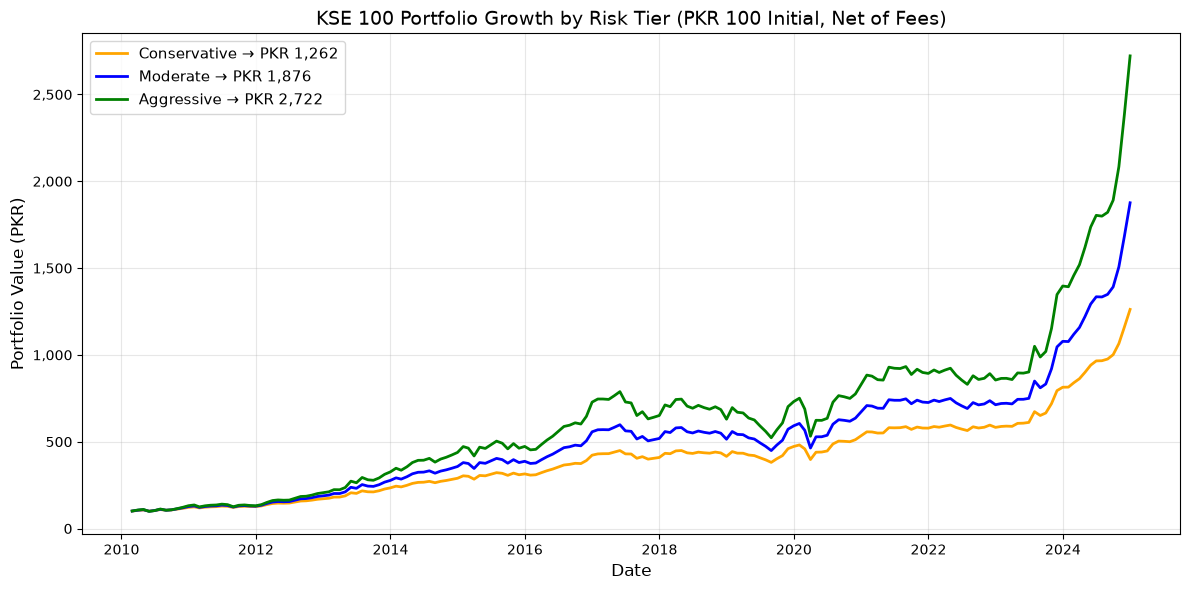

Chart saved to docs/portfolio_growth_by_risk_tier.png


In [15]:
# ========================================
# CHART: Portfolio Growth by Risk Tier
# ========================================
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'Conservative': 'orange', 'Moderate': 'blue', 'Aggressive': 'green'}

for tier_name in risk_tiers.keys():
    ax.plot(portfolio_growth.index, portfolio_growth[tier_name],
            label=f"{tier_name} → PKR {portfolio_growth[tier_name].iloc[-1]:,.0f}",
            color=colors[tier_name], linewidth=2)

ax.set_title('KSE 100 Portfolio Growth by Risk Tier (PKR 100 Initial, Net of Fees)', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Portfolio Value (PKR)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\docs\portfolio_growth_by_risk_tier.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to docs/portfolio_growth_by_risk_tier.png")

In [16]:
# Save the blended portfolio returns for use in Stage 4
portfolio_returns.to_csv(
    r'C:\Users\MuhammadIbrahimBinAl\kse30-portfolio-builder\data\processed\portfolio_returns.csv'
)

print("Portfolio returns saved to data/processed/portfolio_returns.csv")
print(f"Rows: {len(portfolio_returns)}")
print(f"Columns: {list(portfolio_returns.columns)}")

Portfolio returns saved to data/processed/portfolio_returns.csv
Rows: 179
Columns: ['Conservative', 'Moderate', 'Aggressive']
